# TFR / ERD-ERS — all subjects

Per-subject work lives in [`src/tfr_batch.py`](../src/tfr_batch.py), the across-subject figures in
[`src/tfr_group.py`](../src/tfr_group.py) and the statistics in
[`src/tfr_stats.py`](../src/tfr_stats.py); this notebook is only the driver.
Choosing which ICA components to remove is the one thing that needs a human, so the work is
split into stages and that decision is written to disk once per subject:

| stage | call | interactive? | writes |
|---|---|---|---|
| 1 | `prepare_subject(subject)` | yes, once per subject | `Cache/<subj>_*`, `Figures/<subj>/ICA/` |
| 2 | `record_exclusions(subject, [...])` | manual decision | `configs/ica_exclusions.json` |
| 3 | `run_tfr_batch()` | no, all subjects at once | `TFRs/*.h5`, `TFRs/tfr_run.json`, `Figures/<subj>/TFR/`, `Figures/<subj>/Contrasts/` |
| 4 | `run_tfr_group()` | no, whole cohort at once | `Figures/Group/` |
| 5 | `run_tfr_stats()` | no, whole cohort at once | `Figures/Group/Stats/` |

**All settings live in the Parameters cell below** — nothing under it needs editing.

Stages 1–4 are descriptive: they say what the cohort looks like. Stage 5 is inferential: it says
which of it survives a test. Read them in that order — a p-value on a map you have not looked at is
not worth much, and a map without a test is not a result.

Stage 3 reads the **cached** epochs, so the component indices you record always refer to exactly
the data ICA was fitted on. Re-running stage 3 is cheap and idempotent — rerun it after revising a
subject's exclusions. `Cache/` is rebuildable and gitignored; delete it whenever you like.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

# Qt backend: stage 1 needs clickable component topographies and a scrollable sources browser
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

import numpy as np
from src.tfr_batch import *
from src.tfr_group import *
from src.tfr_stats import *

print('project root     :', project_paths().root)
print('subjects         :', list_subjects())
print('electrode groups :', list(ELECTRODE_GROUPS))

## Parameters — the only cell you need to edit

Three dicts, because they invalidate different things:

| dict | what it controls | changing it means |
|---|---|---|
| `PARAMS` | preprocessing, as `EEG_Preprocessing` consumes it | the epoch cache is rebuilt **and the recorded ICA components stop being valid** — that subject must be re-reviewed |
| `TFR` | the time-frequency estimation and the figures | only `TFRs/*.h5` and the figures are recomputed; the ICA review stands |
| `STATS` | the stage-5 statistical design | nothing upstream is touched — but see the warning below |

`check_tfr_params` and `check_stats_params` enforce that split and the rules that would otherwise
fail deep inside MNE or produce a quietly wrong figure — a baseline that crosses the cue, a band
outside the estimated range, an active window that overlaps the baseline, a misspelled key.
`describe_tfr_params` / `describe_stats_params` print the dicts back with `*` on anything that
departs from the library default, and derive the analysis window `T` and the spectral smoothing
that follow from `freqs` and `n_cycles`.

**`STATS` is a pre-registration, not a setting.** The other two dicts you tune until the pipeline
does what you want. This one you fix *before* looking at the result: every contrast in it costs
every other contrast power through the Holm correction, and a contrast added after seeing the maps
is a different test with an error rate nobody can compute. `run_tfr_stats` records the whole dict in
`tfr_stats_summary.json` so what was tested is recoverable later.

**`TFR_LABEL`.** `tfr.save(..., overwrite=True)` and every figure write are unconditional, so
re-running with different settings destroys the previous run — which is why `TFRs_morlet/` and
`TFRs_percent/` exist as hand-made copies. Set `TFR_LABEL` to a name and this run's outputs nest
under `TFRs/<label>/` and `Figures/<label>/` instead. Leaving it `None` reproduces the current flat
layout exactly. `Cache/` and `configs/ica_exclusions.json` stay shared either way — the ICA review
is per subject, not per TFR setting.

**`STATS_TFR_LABEL` is separate on purpose.** It picks which tree the *tests* read, independently of
which one you last rendered figures into, so the inference does not silently change when you switch
`TFR_LABEL`. It defaults to `None` — the logratio tree — because power ratios are multiplicative and
right-skewed and the log makes the per-subject differences much closer to symmetric, which is what
both the sign-flip null and the t-statistic want.

**Why the ICA components are pinned.** A component *index* only means something for the
decomposition it was picked from. Change a preprocessing param, rebuild, and ICA refits with a
different component ordering, so the recorded indices would still apply cleanly while removing the
wrong sources. `record_exclusions` now stamps a fingerprint of the params the review was made
against, and stage 3 refuses rather than applying a stale one. The `stale` column in
`review_status()` shows it ahead of time.

In [ ]:
# ══ PARAMETERS ═══════════════════════════════════════════════════════════════════
ELECTRODE_GROUP_NAMES = 'F+AF+FP+PO+O+FC+C+CP+P'   # all 9 groups = the 64-ch montage
TFR_LABEL = 'percent'   # None -> TFRs/ and Figures/ exactly as today. A string nests both
                        # under it, so a sweep cannot overwrite the previous run.
                        # 'percent' keeps this run clear of the logratio results in TFRs/,
                        # and of the pre-label hand-made copy in TFRs_percent/.

# ── PREPROCESSING ────────────────────────────────────────────────────────────────
#    Rebuilds the epoch cache AND voids every recorded ICA review.
PARAMS = default_params(electrode_group_names=ELECTRODE_GROUP_NAMES)
PARAMS['desired_events'] = ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest']
PARAMS['PerformAvgRef']  = True     # average re-reference
PARAMS['AddRefChannel']  = False    # off here: the FC group above has no FCz to rebuild
PARAMS['CenterByClass']  = True     # per-class mean removal -> the TFRs are INDUCED power
PARAMS['PerformCsd']     = False    # CSD is applied after ICA instead, in stage 3
PARAMS['filter_method']  = 'fir'
PARAMS['LowPass']        = 1        # 1 Hz high-pass, which is what ICA needs
PARAMS['HighPass']       = None     # no low cut here; TFR['lowpass'] does it in stage 3
PARAMS['epoch_tmin']     = -5       # epoch crop, s relative to cue
PARAMS['epoch_tmax']     = 6
PARAMS['bad_electrodes'] = {}       # deliberately empty: ICA/ICLabel handles noisy
                                    # channels, and dropping per-subject bads would give
                                    # every subject a different montage and break stacking
#   The remaining default_params keys (n_components, filters_bands, classifier_window_*,
#   augmentation_params, windowed_prediction_params, n_components_fbcsp, pipeline_name)
#   belong to the classifier stack and reach nothing on this path. The readback below
#   lists them under 'unused here' so it is not a guess.

# ── TFR ──────────────────────────────────────────────────────────────────────────
#    Only recomputes TFRs/*.h5 and the figures. No cache rebuild, no re-review.
TFR = default_tfr_params()

TFR['freqs']          = np.arange(4, 35)   # 4-34 Hz
TFR['n_cycles']       = None               # None -> = freqs, so T = 1.0 s at every freq
TFR['time_bandwidth'] = 4.0                # smoothing bandwidth = time_bandwidth / T
TFR['decim']          = 10                 # 500 -> 50 Hz
TFR['lowpass']        = 40                 # applied to the epochs before the TFR
TFR['n_jobs']         = -1

TFR['mode']          = 'percent'           # (power - baseline) / baseline. MNE's 'percent'
                                           # is a FRACTION, not a %: -0.5 IS a 50% ERD.
TFR['baseline']      = (-2, -0.5)          # inside fixation on every trial, with T/2 guard
TFR['active_window'] = (0.5, 3.5)          # what every topomap / band map averages over
TFR['bands']         = {'Mu': (8, 13), 'Beta': (13, 30)}

TFR['vlim']          = (-0.75, 0.75)  # the FIXED-scale figures: per-subject topo/bands,
                                      # the contrasts, and their group equivalents.
                                      # -0.75 = 75% ERD. The scale is symmetric but the
                                      # data is not: ERD floors at -1, ERS is unbounded,
                                      # so strong ERS clips before any ERD does.
TFR['autoscale_pct'] = 90             # the two AUTOSCALED figures (subject grid, grand-
                                      # average panel), which vlim does not reach. Each
                                      # still scales to its own band, but to this
                                      # percentile of |value| rather than the max, so the
                                      # extremes stop setting the scale. 100 = max =
                                      # nothing clips. The panel needs a LOW value to move
                                      # at all: averaging 10 subjects has already removed
                                      # the tail the grid still has, so 98 halves the grid
                                      # (Mu 1.02 -> 0.51) but barely touches the panel
                                      # (0.31 -> 0.29). At 90: grid 0.33, panel 0.18.
TFR['cmap']       = 'RdBu_r'
TFR['figure_dpi'] = 150

TFR['ica_n_components']       = None        # None -> len(ch_names) - 1
TFR['ica_decim']              = 3
TFR['ica_random_state']       = 97          # changing this reorders the components
TFR['ica_method']             = 'fastica'
TFR['iclabel_exclude_labels'] = ['eye blink', 'eye movement', 'muscle artifact']

# ── STATISTICS (stage 5) ─────────────────────────────────────────────────────────
#    Reads the TFRs and writes nothing upstream. PRE-SPECIFY THIS: a contrast added
#    after seeing the maps is a different test with a different error rate.
STATS_TFR_LABEL = None  # which tree the TESTS run on. None = TFRs/, the logratio tree.
                        # Deliberately not 'percent': power ratios are multiplicative and
                        # right-skewed, and the log makes the per-subject differences much
                        # closer to symmetric — which is what both the sign-flip null and
                        # the t-statistic want. percent stays the tree for REPORTING
                        # effect magnitudes, not the one for inference.
STATS = default_stats_params()
STATS['active_window'] = TFR['active_window']   # keep the tested window and the plotted
STATS['bands']         = TFR['bands']           # bands identical to the figures'

# ── what to run ──────────────────────────────────────────────────────────────────
SUBJECT_NAME   = 'SK'    # stages 1-2, one subject at a time
FORCE          = False   # stage 1: ignore the cache and rebuild
SUBJECTS       = None    # stages 3-5: None = every reviewed subject
SAVE_H5        = True
SAVE_FIGS      = True
SAVE_CONTRASTS = True
RUN_CLUSTER    = True    # stage 5 tier 2; the expensive half. False = tier 1 only.

# ─────────────────────────────────────────────────────────────────────────────────
paths = project_paths(label=TFR_LABEL)
stats_paths = project_paths(label=STATS_TFR_LABEL)
check_tfr_params(PARAMS, TFR, label=TFR_LABEL, paths=paths)
check_stats_params(STATS, tfr_params=TFR)   # the cohort-dependent checks run in stage 5
describe_tfr_params(PARAMS, TFR)
describe_stats_params(STATS)

print(f"\ntfrs    : {paths.tfrs.relative_to(paths.root)}")
print(f"figures : {paths.figures.relative_to(paths.root)}")
print(f"cache   : {paths.cache.relative_to(paths.root)}  (shared across labels)")
print(f"stats   : {stats_paths.tfrs.relative_to(stats_paths.root)}  (tested tree)")
print()
review_status(paths=paths)

## Stage 1 — preprocess one subject and fit ICA

Set `SUBJECT_NAME` in the Parameters cell and run this one. It loads and preprocesses every
`<subject>_MI*.xdf` recording (montage, average reference, 1-100 Hz + 50 Hz notch, epochs -5 to 6 s
around the cue), concatenates them, fits ICA on the result and classifies the components with
ICLabel. Epochs + ICA are cached, so re-running is instant; set `FORCE = True` to rebuild from the
raw files.

All 64 channels are kept for every subject — no per-subject bad-electrode dropping — so the TFRs
stack across subjects for group analysis. Noisy channels are dealt with here, as ICA components.

Three windows open:

- **component topographies** — click one to open its properties (spectrum, epochs image)
- **sources browser** — trials are colour-coded by condition, with a marker at each cue
- **ICLabel summary** — the full 7-class probability per component; hatched = ICLabel's suggestion

Saved to `Figures/<subject>/ICA/` regardless of what you decide.

[SK] loading cached epochs and ICA from Cache/ (pass force=True to rebuild)
Reading C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\SK_pre_ica-epo.fif ...
    Found the data of interest:
        t =   -5000.00 ...    6000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
162 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\SK-ica.fif ...
Now restoring ICA solution ...
Ready.
Creating RawArray with float64 data, n_channels=64, n_times=891162
    Range : 0 ... 891161 =      0.000 ...  1782.322 secs
Ready.
  !! WARNING: SK's cache was built with different preprocessing parameters (filter_method). Rerun prepare_subject('SK', force=True).
  saved Figures\SK\ICA\components.png
  saved Figures\SK\ICA\iclabel.png
Creating RawArray with float64 data, n_channels=63, n_times=891162
    Range : 0 ... 891161 =      0.000 ...  1782.322 secs
Ready.
Using qt as 2D backend.


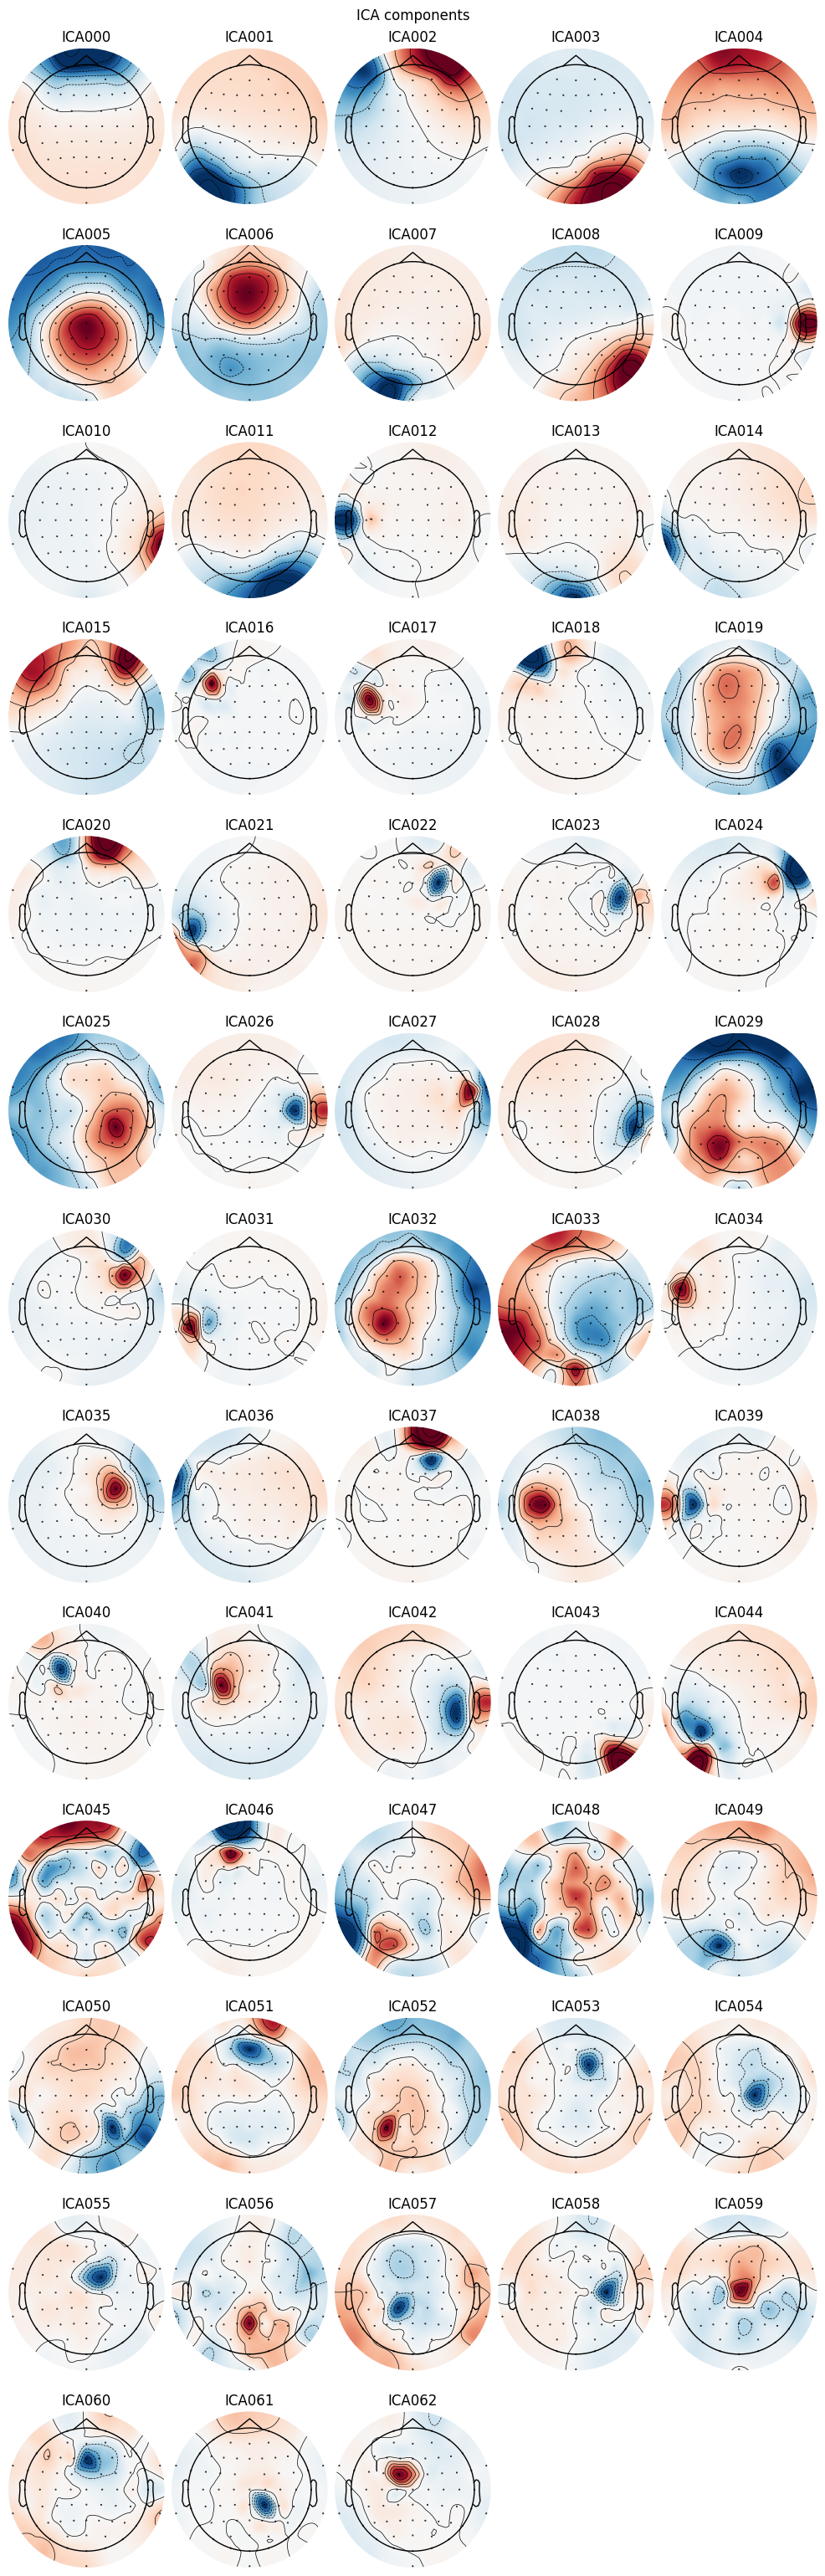

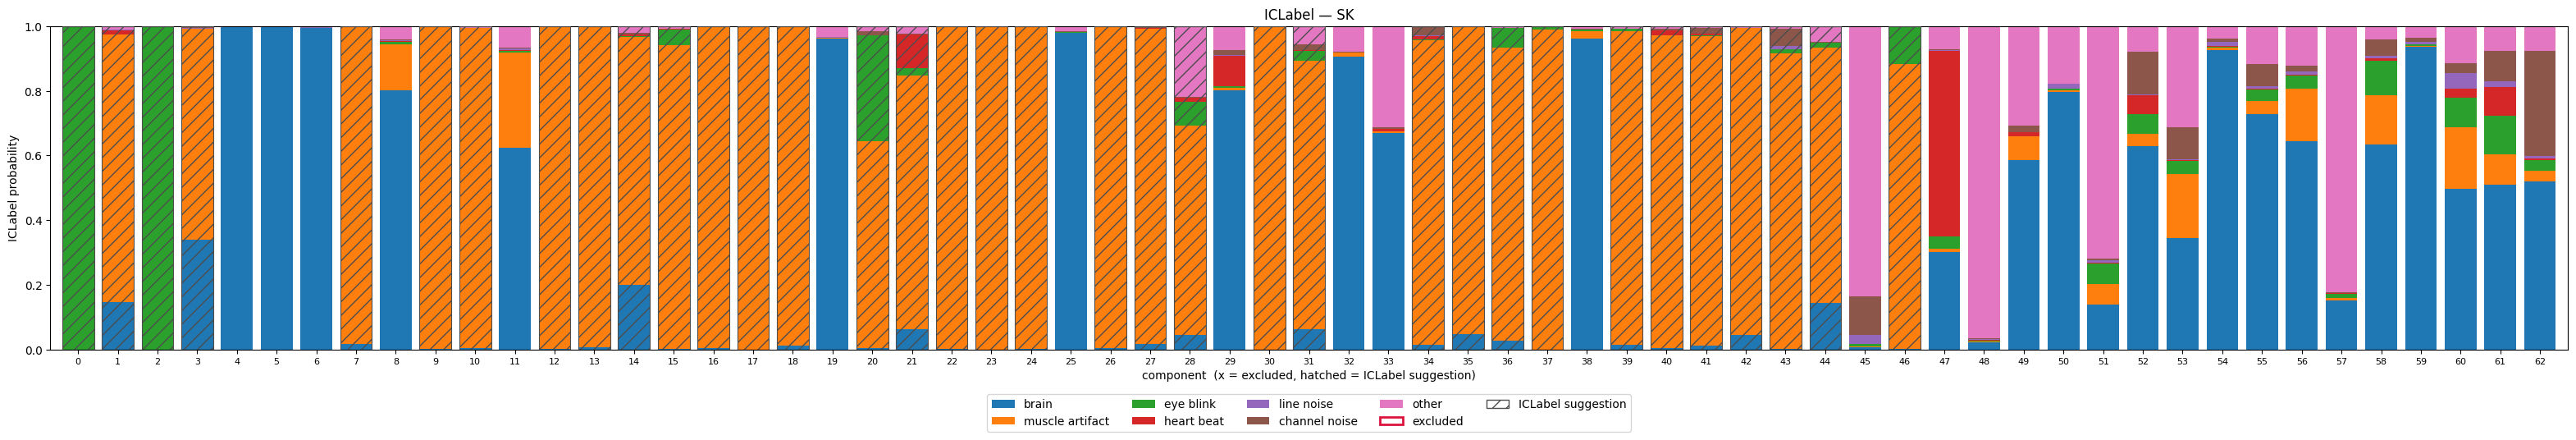


[SK] ICLabel suggests excluding: [0, 1, 2, 3, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 26, 27, 28, 30, 31, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46]
[SK] already recorded: [0, 1, 2, 3, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 26, 27, 28, 30, 31, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46]  (no note, reviewed 2026-08-04)

Review the plots, then record your decision with e.g.:
    record_exclusions('SK', [0, 1, 2, 3, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 26, 27, 28, 30, 31, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46], note='')


In [17]:
state = prepare_subject(SUBJECT_NAME, force=FORCE,
                        params_dict=PARAMS, tfr_params=TFR, paths=paths)

## Stage 2 — record which components to remove

`state['suggested']` is ICLabel's suggestion, and it is deliberately trigger-happy (on subject BA it
flagged 21 of 59 components where 7 were actually artifactual). Treat it as a shortlist: keep the
clear eye-blink / eye-movement / EMG components and anything with a physiologically implausible
topography, and leave borderline "muscle" components that carry real sensorimotor rhythm alone.

Edit the list below and run the cell. It merges into `configs/ica_exclusions.json`, so it is safe to
call again later to revise a subject — just rerun stage 3 for them afterwards.

The entry also records a fingerprint of the preprocessing params it was reviewed against. If you
later change `PARAMS` and rebuild, stage 3 will refuse to apply these indices rather than silently
removing the wrong components, and `review_status()` flags the subject in its `stale` column.

In [18]:
record_exclusions(SUBJECT_NAME, state['suggested'], note='', paths=paths)

# Or paste an explicit list — state['suggested'] is only a shortlist:
# record_exclusions(SUBJECT_NAME, [0, 1, 2, 3, 7, 9, 10], note='blinks + left temporal EMG',
#                   paths=paths)

[SK] recorded 35 component(s) to remove: [0, 1, 2, 3, 7, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 26, 27, 28, 30, 31, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46]


{'exclude': [0,
  1,
  2,
  3,
  7,
  9,
  10,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  20,
  21,
  22,
  23,
  24,
  26,
  27,
  28,
  30,
  31,
  34,
  35,
  36,
  37,
  39,
  40,
  41,
  42,
  43,
  44,
  46],
 'note': '',
 'reviewed': '2026-08-04',
 'params_fingerprint': 'f02d690e3103'}

Now go back to the Parameters cell, change `SUBJECT_NAME` to the next subject, and repeat stages
1–2. `review_status()` below shows who is still outstanding.

In [3]:
review_status(paths=paths)

TFR label: 'percent'  ->  TFRs\percent
subject   files  cached  reviewed  removed  stale  tfrs   note
AEH           3     yes       yes       24      ?     4   
AN            4     yes       yes       12      ?     4   
BA            3     yes       yes       24      ?     4   
EA            4     yes       yes       38      ?     4   
EE            3     yes       yes       23      ?     4   
ID            3     yes       yes       19      ?     4   
LD            3     yes       yes       23      ?     4   
NS            4     yes       yes       25      ?     4   
NZ            4     yes       yes       24      ?     4   
SK            5     yes       yes       35      -     4   

all 10 subject(s) reviewed — run_tfr_batch() is ready


[{'subject': 'AEH',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 24,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'AN',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 12,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'BA',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 24,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'EA',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 38,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'EE',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 23,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'ID',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 19,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'LD',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 23,
  'stale_review': None,


## Stage 3 — TFRs and figures for every reviewed subject

For each subject: apply the recorded ICA exclusions to the cached epochs, convert to CSD, low-pass
at `TFR['lowpass']`, then per condition compute a multitaper TFR over `TFR['freqs']` and baseline it
against `TFR['baseline']` in `TFR['mode']`. The Parameters cell prints the analysis window `T` and
the spectral smoothing those settings imply.

Per subject that writes:

- `TFRs/<subject>_<event>_tfr.h5` — one per condition, which stage 4 below aggregates
- `Figures/<subject>/TFR/` — `<event>_topo`, `<event>_joint`, `<event>_bands` per condition
- `Figures/<subject>/Contrasts/` — every pairwise condition difference
- `Figures/<subject>/ICA/iclabel_final.png` — the components that were actually removed

and once per batch, `TFRs/tfr_run.json` — both params dicts in full, the git commit, the library
versions and the per-subject exclusions, so a TFR can be traced back to what produced it.

Figures render on the `Agg` backend so a full run doesn't open ~180 Qt windows; the Qt backend is
restored when the batch finishes. A subject that fails is reported in the summary table and skipped
rather than aborting the run — rerun those via `SUBJECTS`.

In [4]:
results = run_tfr_batch(SUBJECTS, save_h5=SAVE_H5, save_figs=SAVE_FIGS,
                        save_contrasts=SAVE_CONTRASTS,
                        params_dict=PARAMS, tfr_params=TFR, paths=paths)

rendering figures on 'Agg' (restoring 'Qt5Agg' afterwards)

[1/10] AEH
  note: [AEH]'s ICA review predates params fingerprinting; assuming it still matches. Re-record it to pin it down.
  !! WARNING: AEH's cache was built with different preprocessing parameters (filter_method). Rerun prepare_subject('AEH', force=True).
Reading C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\AEH_pre_ica-epo.fif ...
    Found the data of interest:
        t =   -5000.00 ...    6000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
165 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\AEH-ica.fif ...
Now restoring ICA solution ...
Ready.
[AEH] removing 24 component(s): [0, 1, 6, 7, 9, 11, 14, 15, 19, 20, 22, 23, 24, 26, 27, 28, 29, 33, 38, 42, 46, 47, 48, 50]  (no note, reviewed 2026-08-03)
Applying ICA — removing components: [0, 1, 6, 7, 9, 11, 14, 15, 19, 20, 22, 23, 24, 26, 2

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    1.9s
[Parallel(n_job

  saved Figures\percent\AEH\ICA\iclabel_final.png
[AEH] computing TFR for MiddleHand (45 epochs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    6.6s


Applying baseline correction (mode: percent)


...

  saved TFRs\percent\SK_LeftHand_tfr.h5
No baseline correction applied
  saved Figures\percent\SK\TFR\LeftHand_topo.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\TFR\LeftHand_joint.png
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\TFR\LeftHand_bands.png
[SK] computing TFR for FixatedRest (28 epochs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s


Applying baseline correction (mode: percent)


[Parallel(n_jobs=-1)]: Done  62 out of  64 | elapsed:    3.2s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    3.2s finished


  saved TFRs\percent\SK_FixatedRest_tfr.h5
No baseline correction applied
  saved Figures\percent\SK\TFR\FixatedRest_topo.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\TFR\FixatedRest_joint.png
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\TFR\FixatedRest_bands.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\Contrasts\MiddleHand_minus_RightHand_joint.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\Contrasts\MiddleHand_minus_LeftHand_joint.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\SK\Contrasts\MiddleHand_minus_FixatedRest_joint.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\pe

## Stage 4 — aggregate figures across subjects

Everything here lives in [`src/tfr_group.py`](../src/tfr_group.py). It reads the
`TFRs/<subject>_<event>_tfr.h5` files written by stage 3 and writes to `Figures/Group/`:

- `Subjects/<band>_subject_grid.png` — **the headline**: rows = subjects, columns = conditions,
  with the grand average as a final `GROUP` row, all on one shared colour scale
- `GrandAverage/grand_average_panel.png` — compact summary, rows = bands, columns = conditions
- `GrandAverage/<event>_{topo,joint,bands}.png` — the same three views as the per-subject figures
- `Contrasts/<cond1>_minus_<cond2>_joint.png` — every pairwise difference
- `tfr_group_summary.json` — which subjects went in, on which grid, under the **whole** `TFR` dict

The cohort is whoever has been ICA-reviewed **and** has every condition on the current TFR grid,
so the figures grow on their own as more subjects come through stages 1–2. `group_status()` shows who
is in and why the others are out. Subjects are never silently dropped, and a subject sitting on a
different frequency / time / channel grid raises rather than being averaged in — `TFRs/` also holds
legacy files from an earlier pipeline (54 channels, 2-34 Hz, `decim=2`, `ClosePalm` labels) for
subjects that no longer have recordings at all.

Set `TFR_LABEL` in the Parameters cell to keep a run's figures instead of overwriting these.

Everything on this page is **descriptive**. Nothing here is a test, the colour scales are chosen to
make the maps readable rather than to mark significance, and no panel has been corrected for the
fact that there are 64 channels × 31 frequencies × 551 times in it. Stage 5 below does the testing.

In [3]:
# Group figures are static, so render them inline rather than in Qt windows
get_ipython().run_line_magic('matplotlib', 'inline')

group_status(paths=paths, events=PARAMS['desired_events'])

TFR label: 'percent'  ->  TFRs\percent
subject    reviewed  events               shape  admitted   why not
AEH             yes     4/4       (64, 31, 551)       yes   
AN              yes     4/4       (64, 31, 551)       yes   
BA              yes     4/4       (64, 31, 551)       yes   
EA              yes     4/4       (64, 31, 551)       yes   
EE              yes     4/4       (64, 31, 551)       yes   
ID              yes     4/4       (64, 31, 551)       yes   
LD              yes     4/4       (64, 31, 551)       yes   
NS              yes     4/4       (64, 31, 551)       yes   
NZ              yes     4/4       (64, 31, 551)       yes   
SK              yes     4/4       (64, 31, 551)       yes   

cohort: N = 10  ['AEH', 'AN', 'BA', 'EA', 'EE', 'ID', 'LD', 'NS', 'NZ', 'SK']


[{'subject': 'AEH',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'AN',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'BA',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'EA',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'EE',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'ID',
  'reviewed': True,
  'events': ['MiddleHand'

In [8]:
results = run_tfr_group(SUBJECTS, events=PARAMS['desired_events'],
                        save_figs=SAVE_FIGS, tfr_params=TFR, paths=paths)

group, grand = results['group'], results['grand']

cohort: N = 10  ['AEH', 'AN', 'BA', 'EA', 'EE', 'ID', 'LD', 'NS', 'NZ', 'SK']
  conditions : MiddleHand, RightHand, LeftHand, FixatedRest
  grid       : 64 ch x 31 freqs (4-34 Hz) x 551 times (-5.00..6.00 s)
rendering figures on 'Agg' (restoring 'module://matplotlib_inline.backend_inline' afterwards)

Mu subject grid
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied

## Stage 5 — group statistics

Everything here lives in [`src/tfr_stats.py`](../src/tfr_stats.py). It reads the same
`TFRs/<subject>_<event>_tfr.h5` files stage 4 does — from `STATS_TFR_LABEL`'s tree, not
`TFR_LABEL`'s — and writes `Figures/Group/Stats/`.

**Why this stage exists now.** It used to say group statistics had to wait for the cohort to grow,
and that was right: the paired test here is exact over sign-flips, and flipping *every* subject's
sign leaves a two-tailed statistic unchanged, so there are really only `2**(N-1)` distinct patterns
and the smallest attainable p is `2 / 2**N`. At N=4 that is **0.125** — no result could ever clear
0.05, whatever the data looked like. At N=10 it is **1/512 ≈ 0.002**, so the test finally has room
to reject.

### Two tiers

| | tier 1 — confirmatory | tier 2 — exploratory |
|---|---|---|
| unit | one number per subject/condition, from an a-priori ROI × band × window | every channel × frequency × time bin |
| test | exact paired sign-flip permutation *t* | cluster-based permutation (Maris & Oostenveld 2007) |
| correction | **tmax** across ROI × band cells (Nichols & Holmes 2002) | cluster-level, across ~112k points |
| power at N=10 | good — this is where the claims come from | poor except for large effects |

Tier 1 runs first on purpose: it costs seconds, and if lateralisation does not come out there,
something upstream is wrong and the expensive pass is not worth starting.

### The contrast family

Four "is there any ERD at all" tests (each condition against its own baseline, tier 1 only) plus
four differences: `RightHand − LeftHand` for lateralisation, `MiddleHand` against each natural hand,
and `MiddleHand − FixatedRest`. FWER is controlled **within** each test and never across them, so
Holm is applied across all eight — which is why adding a contrast weakens every other one, and why
`STATS` is a pre-registration rather than a knob.

`MiddleHand − FixatedRest` needs reading carefully: both sides are *already* baselined to fixation,
so it is not third-arm ERD against doing nothing. It is what is left after removing whatever the cue
evokes in every condition alike. The printed output repeats this beside the number.

### How to read a cluster

A significant cluster licenses the claim **"the conditions differ"**. It does **not** establish that
they differ *at* those channels, times or frequencies — cluster extent is not a confidence interval
on where the effect is (Sassenhagen & Draschkow 2019, *Psychophysiology*). The topographic figures
this stage saves are descriptive summaries of where the significant bins happened to fall, and they
are labelled as such on the figure itself, because they are exactly the kind of picture that invites
the forbidden reading.

Set `RUN_CLUSTER = False` in the Parameters cell for tier 1 only. Tier 2 is minutes to tens of
minutes per contrast, four contrasts, on `n_jobs = -1`.

In [ ]:
stats = run_tfr_stats(SUBJECTS, events=PARAMS['desired_events'],
                      stats_params=STATS, tfr_params=TFR,
                      run_cluster=RUN_CLUSTER, save_figs=SAVE_FIGS,
                      paths=stats_paths)

tier1, tier2 = stats['tier1'], stats['tier2']

In [ ]:
# Re-run ONE cluster contrast — for tuning cost, not for hunting a result.
# Narrowing the window or the band after seeing a null is exactly the move that makes a
# p-value meaningless, so if you change these, change them in STATS and re-run everything.
#
# group = stats['group']
# result = run_cluster_test(group, 'RightHand', 'LeftHand', STATS)

# Tier 1 on its own (seconds, no cluster pass):
# tier1 = run_roi_tests(stats['group'], STATS)

# The per-subject values behind tier 1, if you want them in a table:
# values = roi_band_values(stats['group'], STATS)
# values[('RightHand', 'left', 'Mu')]   # one number per subject, in group.subjects order

In [12]:
SUBJECTS       = ['BA','AEH','AN','ID','LD','NS','EE','NZ']   